In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# KMeans
from sklearn.cluster import KMeans

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("Crops.csv")
df.head()

,Crop,Area harvested (km2),Gross Production (m tonnes),Yield per km2 (tonnes),Gross Production value ($bn),Value per km2,SourceName,Source,Wikipedia Page,Image,Main Producer (Quantity),"Main Producer ($), if different","Metric Tonnes Produced (by Main Producer, Quantity)",Status
0,Cannabis,"6,418",0.070,11,306,"47,678,404",UNODC,https://www.unodc.org/documents/wdr2014/World_...,http://en.wikipedia.org/wiki/Cannabis,http://upload.wikimedia.org/wikipedia/commons/...,Mexico,NaN,"38,760",Drug
1,Coca (cocaine),"1,337",0.220,164,50,"37,696,335",UNODC,https://www.unodc.org/documents/wdr2014/World_...,http://en.wikipedia.org/wiki/Coca,http://upload.wikimedia.org/wikipedia/commons/...,Columbia,NaN,"231,700 (potential production of sun dried lea...",Drug
2,Opium Poppy,"2,967",0.007,2,18,"5,954,246",UNODC,https://www.unodc.org/documents/wdr2014/World_...,http://en.wikipedia.org/wiki/Papaver_somniferum,http://upload.wikimedia.org/wikipedia/commons/...,Afghanistan,NaN,"5,500 (potential production of oven-dry opium,...",Drug
3,Barley,"495,260",133.000,269,18,"36,345",FAOSTAT,http://faostat3.fao.org/,http://en.wikipedia.org/wiki/Barley,http://upload.wikimedia.org/wikipedia/commons/...,Russia,France,"16,938,000",Legal Crop
4,Beans,"536,762",24.000,45,16,"29,808",FAOSTAT,http://faostat3.fao.org/,http://en.wikipedia.org/wiki/Bean,http://upload.wikimedia.org/wikipedia/commons/...,Myanmar,India,"3,900,000",Legal Crop


In [4]:
df.columns = df.columns.str.strip()        # remove spaces
df.columns = df.columns.str.replace(" ", "_")  # replace spaces with underscores
df.columns = df.columns.str.lower()        # optional: make lowercase

In [6]:
for col in df.columns:
    print(repr(col))

'crop'
'area_harvested_(km2)'
'gross_production_(m_tonnes)'
'yield_per_km2_(tonnes)'
'gross_production_value_($bn)'
'value_per_km2'
'sourcename'
'source'
'wikipedia_page'
'image'
'main_producer_(quantity)'
'main_producer_($),_if_different'
'metric_tonnes_produced_(by_main_producer,_quantity)'
'status'


In [7]:
expected_cols = ['Soil_Type', 'Rainfall', 'Temperature', 'Fertilizer']

missing = [col for col in expected_cols if col not in df.columns]
print("Missing columns:", missing)

Missing columns: ['Soil_Type', 'Rainfall', 'Temperature', 'Fertilizer']


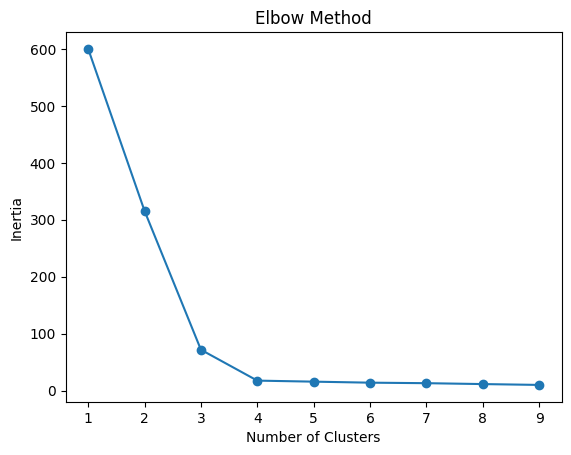

In [10]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create sample data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# Elbow method
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
print([col for col in df.columns])

['crop', 'area_harvested_(km2)', 'gross_production_(m_tonnes)', 'yield_per_km2_(tonnes)', 'gross_production_value_($bn)', 'value_per_km2', 'sourcename', 'source', 'wikipedia_page', 'image', 'main_producer_(quantity)', 'main_producer_($),_if_different', 'metric_tonnes_produced_(by_main_producer,_quantity)', 'status']


In [17]:
print(df.columns)          # See actual column names
print(df.head())          # Preview data
print(df.columns.tolist())  # Check for hidden spaces

Index(['crop', 'area_harvested_(km2)', 'gross_production_(m_tonnes)',
       'yield_per_km2_(tonnes)', 'gross_production_value_($bn)',
       'value_per_km2', 'sourcename', 'source', 'wikipedia_page', 'image',
       'main_producer_(quantity)', 'main_producer_($),_if_different',
       'metric_tonnes_produced_(by_main_producer,_quantity)', 'status'],
      dtype='str')
             crop  ...      status
0        Cannabis  ...        Drug
1  Coca (cocaine)  ...        Drug
2     Opium Poppy  ...        Drug
3          Barley  ...  Legal Crop
4           Beans  ...  Legal Crop

[5 rows x 14 columns]
['crop', 'area_harvested_(km2)', 'gross_production_(m_tonnes)', 'yield_per_km2_(tonnes)', 'gross_production_value_($bn)', 'value_per_km2', 'sourcename', 'source', 'wikipedia_page', 'image', 'main_producer_(quantity)', 'main_producer_($),_if_different', 'metric_tonnes_produced_(by_main_producer,_quantity)', 'status']


In [19]:
print(df.columns)
print(df.head())

Index(['crop', 'area_harvested_(km2)', 'gross_production_(m_tonnes)',
       'yield_per_km2_(tonnes)', 'gross_production_value_($bn)',
       'value_per_km2', 'sourcename', 'source', 'wikipedia_page', 'image',
       'main_producer_(quantity)', 'main_producer_($),_if_different',
       'metric_tonnes_produced_(by_main_producer,_quantity)', 'status'],
      dtype='str')
             crop  ...      status
0        Cannabis  ...        Drug
1  Coca (cocaine)  ...        Drug
2     Opium Poppy  ...        Drug
3          Barley  ...  Legal Crop
4           Beans  ...  Legal Crop

[5 rows x 14 columns]
